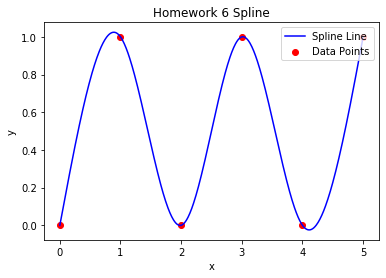

In [3]:
import numpy as np
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]
        B[i - 1] = 2*(h[i-1]+h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6*( ((y[i+1]-y[i])/h[i]) - ((y[i]-y[i-1])/h[i-1]))
    return A, B, C, D, h
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])
A, B, C, D, h_glob= setup_tridiagonal_matrix(x, y)



def thomas_algorithm(a, b, c, d):
    
    n = len(b)
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x
        

result = thomas_algorithm(A[1:], B, C[:-1], D)
M_list = np.concatenate(([0], result, [0]))

def evaluate_spline(xeval, x, y, M_list, h_glob):
    n = len(x)
    i = 0
    for j in range(n - 1):
        
        if x[j] <= xeval and  xeval <= x[j+1]:
            i = j
            break   
    dx = xeval - x[i]
    a = y[i]
    b = (y[i+1] - y[i])/h_glob[i] - h_glob[i]*(M_list[i+1] + 2*M_list[i])/6
    c = M_list[i]/2
    d = (M_list[i+1] - M_list[i]) / (6 * h_glob[i])
    
    return a + b*dx + c*dx**2 + d*dx**3


import matplotlib.pyplot as plt

x_plot = np.linspace(x[0], x[-1], 500)
y_plot = []
for val in x_plot:
    addy = evaluate_spline(val, x, y, M_list, h_glob)
    y_plot.append(addy)
plt.scatter(x, y, color='red', label='Data Points')
plt.plot(x_plot, y_plot, color='blue', label='Spline Line')
plt.title('Homework 6 Spline')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()